## ✨ Introdução a Regressão Linear

Este projeto tem como objetivo analisar os fatores que influenciam os salários na área de dados, utilizando o modelo de regressão linear para prever valores com base em diferentes características dos profissionais.

A partir de variáveis como idade, experiência profissional, localização e outros aspectos relevantes, busca-se identificar padrões e relações que impactam diretamente a remuneração. A proposta vai além da previsão: compreender como esses fatores se conectam e quais têm maior peso na construção das desigualdades salariais dentro do setor.

Durante o desenvolvimento, foram realizadas etapas de limpeza, exploração e tratamento dos dados, seguidas da construção e avaliação do modelo preditivo. A análise foi conduzida utilizando Python e bibliotecas voltadas à ciência de dados, permitindo extrair insights consistentes e orientados por dados reais.

Este projeto reflete não apenas a aplicação de técnicas estatísticas, mas também um olhar analítico sobre o mercado de trabalho em dados, trazendo uma perspectiva prática e relevante para tomada de decisão.

In [ ]:
import pandas as pd


In [ ]:
dados = pd.read_excel('/content/drive/MyDrive/Programaria/analise_dados_mod7_(1).xlsx')

In [ ]:
dados.head()

In [ ]:
dados.columns

In [ ]:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

In [ ]:
dados = dados[dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'] == 'Empregado (CLT)'] ## Filtrando tudo o que seja empregado CLT

In [ ]:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

In [ ]:
dados['COR/RACA/ETNIA'].value_counts()

In [ ]:
### Retirando números pequenos

lista_retirar = ['Prefiro não informar', 'Outra', 'Indígena']

In [ ]:
dados = dados[~dados['COR/RACA/ETNIA'].isin(lista_retirar)]
## Para retirar oque está na lista e não manter utilizamos o acento til

In [ ]:
dados['NAO_BRANCA'] = dados['COR/RACA/ETNIA'].apply(lambda x:1 if x!= 'Branca' else 0)

In [ ]:
dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].value_counts()

In [ ]:
dados['TEMPO_EXPERIENCIA'] = dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].str.extract(r'(\d+)')
## Queremos pegar o primeiro digito da coluna tempo de experiencia o + significa que
##se após o primeiro numero tiver mais um número ele vai trazer os dois.

In [ ]:
dados['TEMPO_EXPERIENCIA'].value_counts()

In [ ]:
dados['NUMERO DE FUNCIONARIOS'].value_counts()

In [ ]:
### Substituir o ponto por nada, valor null

dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.replace('.','')

In [ ]:
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.extract(r'(\d+)')

In [ ]:
dados['NUMERO DE FUNCIONARIOS'].value_counts(dropna=False)

In [ ]:
dados['TEMPO_EXPERIENCIA'].value_counts(dropna=False)

In [ ]:
dados['TEMPO_EXPERIENCIA'] = dados['TEMPO_EXPERIENCIA'].fillna(0) ##Preencher as colunas de null com 0

In [ ]:
dados['TEMPO_EXPERIENCIA'].value_counts()

In [ ]:
## Criando coluna de instafisfacao

dados['INSATISFACAO'] = 0

In [ ]:
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'INSATISFACAO'] = dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if 'Salário' in x else 0 )

In [ ]:
dados['INSATISFACAO'].value_counts()

In [ ]:
dados['NIVEL DE ENSINO'].value_counts()

In [ ]:
dados['NIVEL DE ENSINO'] =dados['NIVEL DE ENSINO'].apply(lambda x: 0 if x== 'Não tenho graduação formal' else
                               1 if x== 'Estudante de Graduação' else
                               2 if x== 'Graduação/Bacharelado' else
                               3 if x== 'Pós-graduação' else
                               4 if x== 'Mestrado' else
                               5 if x== 'Doutorado ou Phd' else -1 )

In [ ]:
dados = dados[['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO', 'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO',
       'NUMERO DE FUNCIONARIOS', 'SALARIO', 'NOVO_NIVEL']]

In [ ]:
dados.columns

In [ ]:
dados= pd.get_dummies(dados, columns=['GENERO', 'SETOR', 'NOVO_NIVEL', 'REGIAO ONDE MORA'], drop_first=True)

In [ ]:
X = dados.drop('SALARIO', axis=1)
y = dados['SALARIO']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler ## Utilizada para normalizar os dados

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train_scaled, y_train)

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
mse = mean_squared_error(y_test, y_pred)

In [ ]:
mse

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

In [ ]:
mae

In [ ]:
r2 = r2_score(y_test, y_pred)

In [ ]:
r2

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred, alpha= 0.5)
plt.xlabel('Valor real')
plt.ylabel('Valor predito')
plt.title('Dispersão dos dados')
plt.plot([min(y_test), max(y_test)],[min(y_test), max(y_test)], color='red', linewidth=2)
plt.show()

In [ ]:
nomes_atributos = X_train.columns

In [ ]:
nomes_atributos

In [ ]:
coefs = pd.DataFrame(model.coef_, columns=['coeficientes'], index=nomes_atributos)

In [ ]:
coefs.sort_values(by='coeficientes', ascending=False)

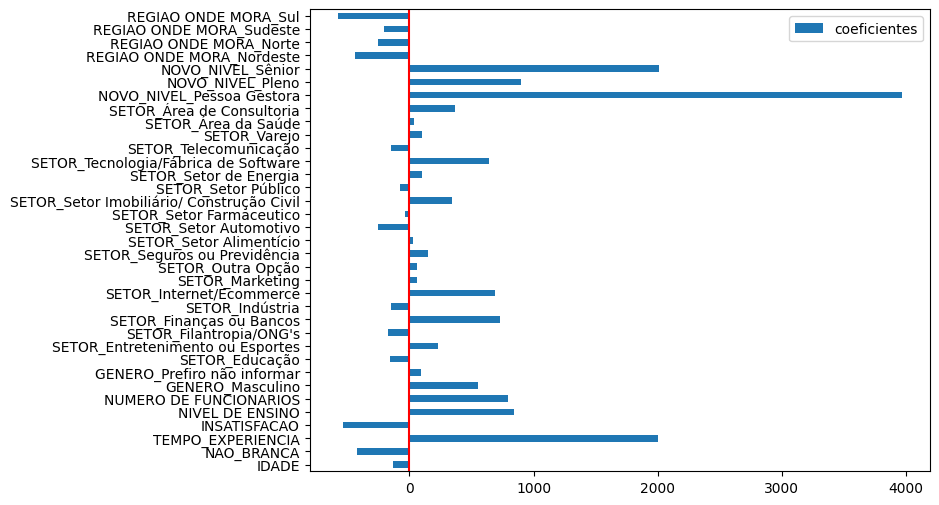

In [151]:
coefs.plot.barh(figsize=(8,6))
plt.axvline(x=0, color='red')